In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flipkart-product/flipkart_product_copy.csv


In [2]:
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer, BertModel,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from torch.cuda.amp import autocast, GradScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN     = 64        
BATCH_SIZE  = 64        
EPOCHS      = 2       
LR          = 2e-5
MODEL_NAME  = 'distilbert-base-uncased'   
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
df = pd.read_csv('/kaggle/input/flipkart-product/flipkart_product_copy.csv', encoding='latin1')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')
df = df.dropna(subset=['Rate'])

def map_sentiment(rate):
    if rate > 3:   return 'Positive'
    elif rate < 3: return 'Negative'
    else:          return 'Neutral'

df['sentiment'] = df['Rate'].apply(map_sentiment)
df['text'] = df['Summary'].fillna('') + ' ' + df['Review'].fillna('')


In [5]:
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9!?.,'\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

print("Class distribution:")
print(df['sentiment'].value_counts())


Class distribution:
sentiment
Positive    148347
Negative     25841
Neutral      15681
Name: count, dtype: int64


In [6]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
NUM_CLASSES = len(label_encoder.classes_)
print(f"Classes: {label_encoder.classes_}")


Classes: ['Negative' 'Neutral' 'Positive']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'].values, df['label'].values,
    test_size=0.15, random_state=42, stratify=df['label']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.12, random_state=42, stratify=y_train
)

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train.reshape(-1, 1), y_train)
X_train_res = X_train_res.flatten()
print(f"After oversampling: {Counter(y_train_res)}")


After oversampling: Counter({2: 110962, 0: 110962, 1: 110962})


In [8]:
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(X_train_res, y_train_res, tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(X_val,       y_val,       tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(X_test,      y_test,      tokenizer, MAX_LEN)

# num_workers=0 to avoid CPU freeze
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
).to(DEVICE)

class_counts  = np.bincount(y_train_res)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scaler    = GradScaler()  # fp16

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        if train:
            optimizer.zero_grad()
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss    = criterion(outputs.logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
        else:
            with torch.no_grad():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss    = criterion(outputs.logits, labels)

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        # Print progress every 100 batches
        if i % 100 == 0:
            print(f"  Batch {i}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader), accuracy_score(all_labels, all_preds), all_preds, all_labels


In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print('='*50)

    tr_loss, tr_acc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, train=True
    )
    vl_loss, vl_acc, _, _ = run_epoch(
        model, val_loader, criterion, train=False
    )

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"\nEpoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} Train Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Val Acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_bert_sentiment.pt')
        print("✓ Best model saved!")


EPOCH 1/2
  Batch 0/5202 | Loss: 1.0946
  Batch 100/5202 | Loss: 1.0450
  Batch 200/5202 | Loss: 0.5565
  Batch 300/5202 | Loss: 0.2115
  Batch 400/5202 | Loss: 0.1642
  Batch 500/5202 | Loss: 0.1838
  Batch 600/5202 | Loss: 0.1359
  Batch 700/5202 | Loss: 0.1512
  Batch 800/5202 | Loss: 0.0864
  Batch 900/5202 | Loss: 0.1018
  Batch 1000/5202 | Loss: 0.2198
  Batch 1100/5202 | Loss: 0.0234
  Batch 1200/5202 | Loss: 0.0640
  Batch 1300/5202 | Loss: 0.0540
  Batch 1400/5202 | Loss: 0.2617
  Batch 1500/5202 | Loss: 0.2054
  Batch 1600/5202 | Loss: 0.1251
  Batch 1700/5202 | Loss: 0.0954
  Batch 1800/5202 | Loss: 0.0834
  Batch 1900/5202 | Loss: 0.0512
  Batch 2000/5202 | Loss: 0.1724
  Batch 2100/5202 | Loss: 0.0415
  Batch 2200/5202 | Loss: 0.0802
  Batch 2300/5202 | Loss: 0.1269
  Batch 2400/5202 | Loss: 0.0541
  Batch 2500/5202 | Loss: 0.0820
  Batch 2600/5202 | Loss: 0.0299
  Batch 2700/5202 | Loss: 0.2451
  Batch 2800/5202 | Loss: 0.0389
  Batch 2900/5202 | Loss: 0.1493
  Batch 300

  Batch 0/446 | Loss: 0.0592
  Batch 100/446 | Loss: 0.1331
  Batch 200/446 | Loss: 0.0186
  Batch 300/446 | Loss: 0.1292
  Batch 400/446 | Loss: 0.0969

Test Accuracy: 0.9605
              precision    recall  f1-score   support

    Negative       0.97      0.98      0.97      3876
     Neutral       0.72      0.93      0.81      2352
    Positive       0.99      0.96      0.98     22253

    accuracy                           0.96     28481
   macro avg       0.89      0.96      0.92     28481
weighted avg       0.97      0.96      0.96     28481



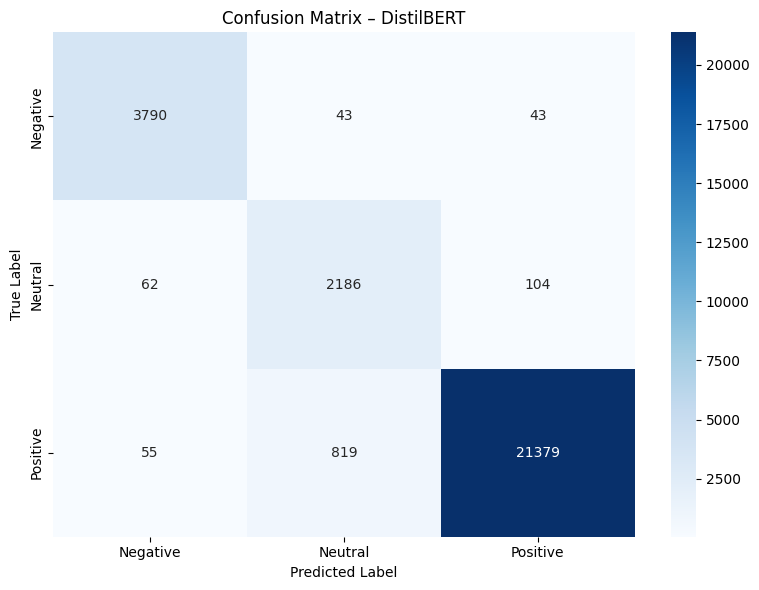

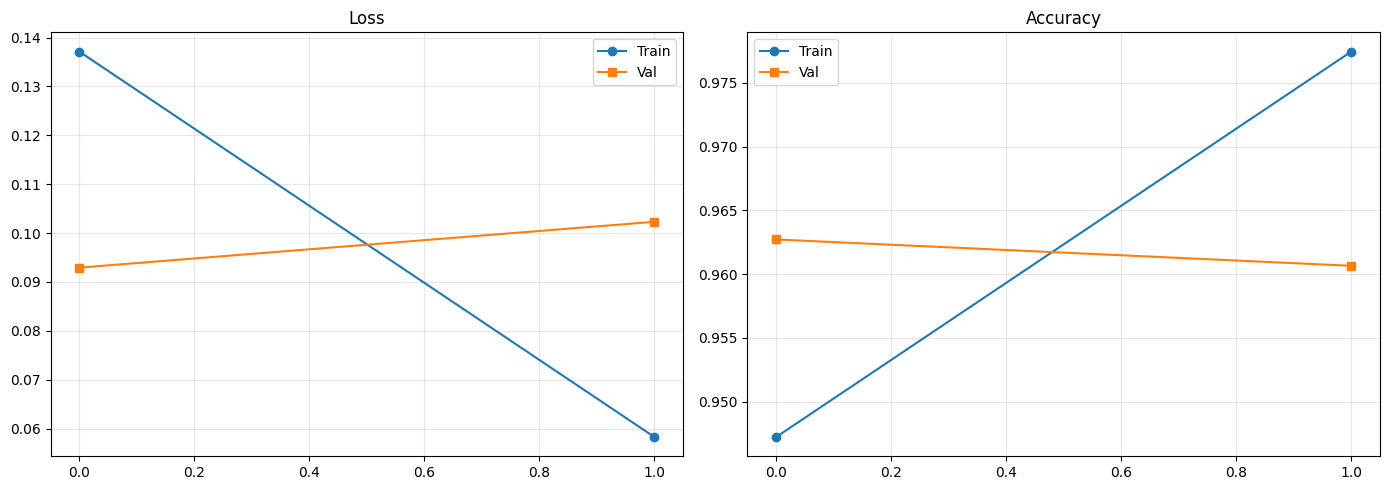

In [12]:
model.load_state_dict(torch.load('best_bert_sentiment.pt'))
_, test_acc, y_pred, y_true = run_epoch(model, test_loader, criterion, train=False)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix – DistilBERT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, vl), title in zip(axes,
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Loss', 'Accuracy']):
    ax.plot(history[tr], label='Train', marker='o')
    ax.plot(history[vl], label='Val',   marker='s')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()


In [13]:
joblib.dump(label_encoder, 'label_encoder.pkl')
tokenizer.save_pretrained('distilbert_tokenizer/')
print("All artifacts saved!")

class SentimentAnalyzer:
    def __init__(self, model, tokenizer, label_encoder):
        self.model         = model.eval().to(DEVICE)
        self.tokenizer     = tokenizer
        self.label_encoder = label_encoder

    @torch.no_grad()
    def predict_sentiment(self, text):
        text     = clean_text(text)
        encoding = self.tokenizer(
            text, max_length=MAX_LEN,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        input_ids      = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)
        outputs        = self.model(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred_idx       = np.argmax(probs)
        prediction     = self.label_encoder.inverse_transform([pred_idx])[0]
        confidence     = float(probs[pred_idx]) * 100
        rating         = 1 if prediction == 'Negative' else 3 if prediction == 'Neutral' else 5
        return prediction, rating, confidence

analyzer = SentimentAnalyzer(model, tokenizer, label_encoder)


All artifacts saved!


In [14]:
def user_interface():
    print("\n" + "="*55)
    print("  Flipkart Review Sentiment Analyzer [DistilBERT]")
    print("="*55)
    print("Enter a product review (or 'quit' to exit)\n")

    while True:
        user_input = input("Review: ").strip()

        if user_input.lower() in ('quit', 'exit'):
            print("Goodbye!")
            break

        if not user_input:
            print("Please enter a valid review.\n")
            continue

        sentiment, rating, confidence = analyzer.predict_sentiment(user_input)

        bar   = "■" * rating + "□" * (5 - rating)
        emoji = {"Positive": "😊", "Neutral": "😐", "Negative": "😞"}

        print("\n── Result ─────────────────────────────")
        print(f"  Sentiment  : {sentiment} {emoji[sentiment]}")
        print(f"  Rating     : [{bar}] {rating}/5")
        print(f"  Confidence : {confidence:.1f}%")
        print("─" * 40 + "\n")

if __name__ == "__main__":
    user_interface()


  Flipkart Review Sentiment Analyzer [DistilBERT]
Enter a product review (or 'quit' to exit)



Review:  This groecery item is fresh and good to use.



── Result ─────────────────────────────
  Sentiment  : Positive 😊
  Rating     : [■■■■■] 5/5
  Confidence : 99.3%
────────────────────────────────────────



Review:  Quality of this fridge is very bad



── Result ─────────────────────────────
  Sentiment  : Negative 😞
  Rating     : [■□□□□] 1/5
  Confidence : 99.9%
────────────────────────────────────────



Review:  Quality of this fan is okayish neither bad nor good.



── Result ─────────────────────────────
  Sentiment  : Neutral 😐
  Rating     : [■■■□□] 3/5
  Confidence : 87.9%
────────────────────────────────────────



Review:  quit


Goodbye!
